# Asian Options

Asian options are options with payoff that depends on the average of the underlying over a certain time interval. Because of this path-dependent nature, the tracking of average price of the underlying adds another layer of consideration to the evolution of the underlying price. Therefore, even with only one underlying asset, the pricing of Asian option has inherently two dimension of analysis.

*Strikes of Asian options can be fixed or floating. In this workbook, we focus on fixed-strike Asian options.

In [ ]:
# Libraries and path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))
FIGURE_DIR = Path.cwd().parent / "docs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Core
from derivlab.core.enums import AverageType, OptionKind

# Product and Model
from derivlab import AsianOption, BlackScholesModel, MarketParams

# Analytical
from derivlab.pricers.analytic.black_scholes import BlackScholesAnalyticPricer

# Monte Carlo
from derivlab.pricers.monte_carlo.engine import MonteCarloPricer, SimulationConfig
from derivlab.pricers.monte_carlo.variance_reduction import ControlVariatePricer, ControlVariateType


## Setup


In [3]:
# Black-Scholes framework
market = MarketParams(spot=100, rate=0.05, dividend=0.0, volatility=0.2)
model = BlackScholesModel(market)

geometric_asian = AsianOption(OptionKind.CALL, strike=100, maturity=1.0, average=AverageType.GEOMETRIC)
arithmetic_asian = AsianOption(OptionKind.CALL, strike=100, maturity=1.0, average=AverageType.ARITHMETIC)

## Average Intuition

For positive paths, the arithmetic average is at least the geometric average. This is why the geometric Asian call serves as a lower-bound style reference for the arithmetic Asian call.


In [4]:
example_paths = np.array([
    [100, 105, 110, 115],
    [100, 95, 90, 85],
])

average_example = pd.DataFrame(
    {
        "Arithmetic average": arithmetic_asian.average_from_paths(example_paths),
        "Geometric average": geometric_asian.average_from_paths(example_paths),
    }
)
average_example

,Arithmetic average,Geometric average
0,110.0,109.924190
1,90.0,89.907312


## Geometric Asian - Analytical Benchmark (continuous monitoring)

The geometric Asian average is analytically tractable under Black-Scholes in continuous monitoring.

In [5]:
geometric_reference_result = BlackScholesAnalyticPricer().price(model, geometric_asian)
geometric_reference = geometric_reference_result.price

geometric_benchmark = pd.DataFrame(
    {
        "Method": "Geometric Asian closed form",
        "Price": geometric_reference,
        "Run time (s)": geometric_reference_result.runtime,
    },
    index=[0],
)
geometric_benchmark


,Method,Price,Run time (s)
0,Geometric Asian closed form,5.546819,0.001929


## Geometric Asian - Monte Carlo

Monte Carlo with a finite number of monitoring dates is a discrete-monitoring approximation, so path-count(M) convergence and monitoring-step(X) convergence have different effects.


In [6]:
M = [10_000, 50_000, 100_000, 500_000]
X = [252, 1000]
geometric_mc_results = []

for m in M:
    for x in X:
        mc_config = SimulationConfig(n_paths=m, n_steps=x, seed=42)
        geometric_mc_result = MonteCarloPricer(mc_config).price(model, geometric_asian)

        geometric_mc_results.extend([{
                                        "MC method": "Plain MC",
                                        "No. of paths": m,
                                        "No. of monitoring steps": mc_config.n_steps,
                                        "Price": geometric_mc_result.price,
                                        "Standard Error": geometric_mc_result.stderr,
                                        "Error vs closed_form (abs)": abs(geometric_mc_result.price - geometric_reference),
                                        "Run time (s)": geometric_mc_result.runtime,
                                    }])

geometric_mc = pd.DataFrame(geometric_mc_results)


In [21]:
display(geometric_mc)

,MC method,No. of paths,No. of monitoring steps,Price,Standard Error,Error vs closed_form (abs),Run time (s)
0,Plain MC,10000,252,5.597535,0.077910,0.050716,0.075836
1,Plain MC,10000,1000,5.539024,0.076488,0.007795,0.184896
2,Plain MC,50000,252,5.557014,0.034509,0.010195,0.245891
3,Plain MC,50000,1000,5.567523,0.034510,0.020704,1.020850
4,Plain MC,100000,252,5.575645,0.024520,0.028827,0.509066
5,Plain MC,100000,1000,5.575952,0.024461,0.029134,2.003062
6,Plain MC,500000,252,5.573712,0.010937,0.026894,2.827657
7,Plain MC,500000,1000,5.552020,0.010889,0.005202,37.332472


## Arithmetic Asian - Monte Carlo and Control Variate

The arithmetic Asian call has no simple closed form under Black-Scholes. Plain Monte Carlo is the natural baseline, and the geometric closed-form price acts as a related lower-bound reference. The geometric Asian payoff is highly correlated with the arithmetic Asian payoff and has a known expectation, making it a powerful control variate.


In [7]:
M = [10_000, 50_000, 100_000, 500_000]
control_variate_results = []
arithmetic_mc_results = []

for m in M:
    mc_config = SimulationConfig(n_paths=m, n_steps=252, seed=42)
    plain_result = MonteCarloPricer(mc_config).price(model, arithmetic_asian)
    control_variate_result = ControlVariatePricer(
                                                        ControlVariateType.GEOMETRIC_ASIAN,
                                                        mc_config,
                                                    ).price(model, arithmetic_asian)
    
    mc_geometric = MonteCarloPricer(mc_config).price(model, geometric_asian)

    arithmetic_mc_results.extend([{
                                    "MC method": "Plain MC",
                                    "No. of paths": m,
                                    "Price": plain_result.price,
                                    "Standard Error": plain_result.stderr,
                                    "Premium vs mc geometric": plain_result.price - mc_geometric.price,
                                    "Run time (s)": plain_result.runtime,
                                }])

    control_variate_results.extend([{
                                    "MC method": "Geometric control variate",
                                    "No. of paths": m,
                                    "Price": control_variate_result.price,
                                    "Standard Error": control_variate_result.stderr,
                                    "correlation": control_variate_result.metadata["correlation"],
                                    "Premium vs mc geometric": control_variate_result.price - mc_geometric.price,
                                    "Run time (s)": control_variate_result.runtime,
                                }])

arithmetic_mc = pd.DataFrame(arithmetic_mc_results)
control_arithmetic_mc = pd.DataFrame(control_variate_results)


In [23]:
display(arithmetic_mc)
display(control_arithmetic_mc)

,MC method,No. of paths,Price,Standard Error,Premium vs mc geometric,Run time (s)
0,Plain MC,10000,5.817900,0.080748,0.220366,0.046168
1,Plain MC,50000,5.773978,0.035753,0.216965,0.195916
2,Plain MC,100000,5.793191,0.025408,0.217546,0.431405
3,Plain MC,500000,5.791004,0.011329,0.217292,2.054896


,MC method,No. of paths,Price,Standard Error,correlation,Premium vs mc geometric,Run time (s)
0,Geometric control variate,10000,5.765359,0.002324,0.999586,0.167824,0.113678
1,Geometric control variate,50000,5.763420,0.001001,0.999608,0.206406,0.233370
2,Geometric control variate,100000,5.763333,0.000707,0.999612,0.187687,0.518253
3,Geometric control variate,500000,5.763156,0.000314,0.999615,0.189443,2.415600


## PDE

Asian options are path-dependent. A one-dimensional Black-Scholes PDE in spot alone is not enough because the running average must become part of the state. There is a wide range of literature attempting to simplify this problem from different angles. One very interesting approach was presented by Vecer (2001), who priced Asian options in the context of options on a traded account (think of it as a fund) and formulates a well-behaved PDE in one spatial variable which is readily solved by finite difference methods (Cerny, 2026). More discoveries were made later with integro-differential equations which works well for names Levy processes. This may be more interesting to experiment in later stage when Levy processes are discussed. 


## Result Plots

For Asians, the geometric option gives a closed-form benchmark. The arithmetic option is then studied through sampling error and the geometric control variate, where the key diagnostic is the reduction in standard error.


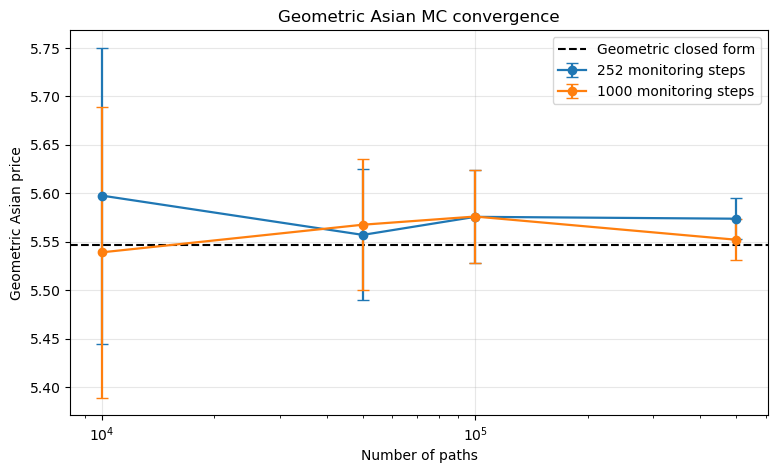

In [10]:
plt.figure(figsize=(9, 5))
plt.axhline(geometric_reference, color="black", linestyle="--", linewidth=1.5, label="Geometric closed form")

for steps, group in geometric_mc.groupby("No. of monitoring steps"):
    plt.errorbar(
        group["No. of paths"],
        group["Price"],
        yerr=1.96 * group["Standard Error"],
        marker="o",
        capsize=4,
        linewidth=1.6,
        label=f"{steps} monitoring steps",
    )

plt.xscale("log")
plt.xlabel("Number of paths")
plt.ylabel("Geometric Asian price")
plt.title("Geometric Asian MC convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "asian_geometric_mc_convergence.png", dpi=200, bbox_inches="tight")
plt.show()


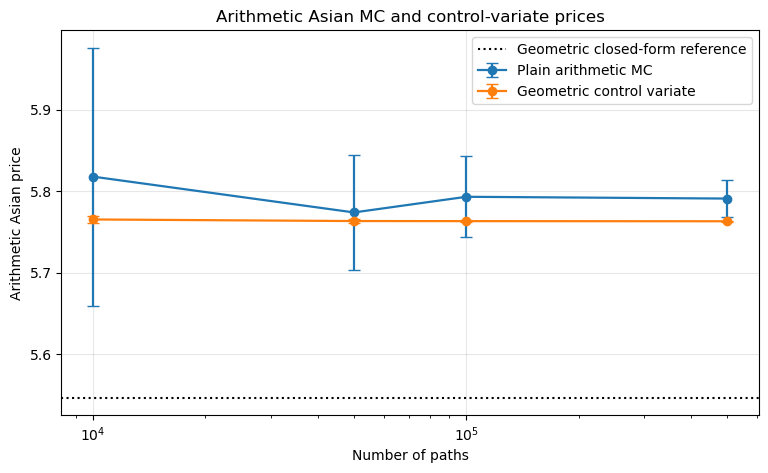

In [13]:
arithmetic_plot_data = [
    ("Plain arithmetic MC", arithmetic_mc),
    ("Geometric control variate", control_arithmetic_mc),
]

plt.figure(figsize=(9, 5))
plt.axhline(geometric_reference, color="black", linestyle=":", linewidth=1.5, label="Geometric closed-form reference")

for label, df in arithmetic_plot_data:
    plt.errorbar(
        df["No. of paths"],
        df["Price"],
        yerr=1.96 * df["Standard Error"],
        marker="o",
        capsize=4,
        linewidth=1.6,
        label=label,
    )

plt.xscale("log")
plt.xlabel("Number of paths")
plt.ylabel("Arithmetic Asian price")
plt.title("Arithmetic Asian MC and control-variate prices")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "asian_arithmetic_control_price.png", dpi=200, bbox_inches="tight")
plt.show()


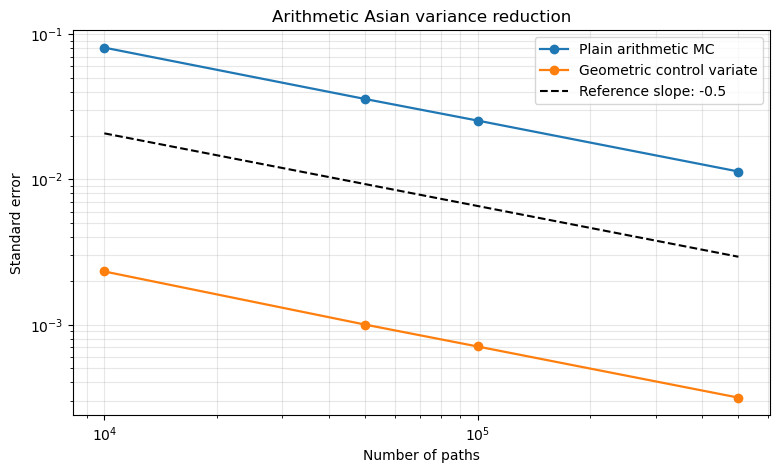

In [26]:
plt.figure(figsize=(9, 5))

for label, df in arithmetic_plot_data:
    plt.plot(
        df["No. of paths"],
        df["Standard Error"],
        marker="o",
        linewidth=1.6,
        label=label,
    )

reference_paths = arithmetic_mc["No. of paths"]
reference_stderr = (arithmetic_mc["Standard Error"].iloc[0] - 0.06) * (reference_paths.iloc[0] / reference_paths) ** 0.5
plt.plot(reference_paths, reference_stderr, color="black", linestyle="--", linewidth=1.5, label="Reference slope: -0.5")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of paths")
plt.ylabel("Standard error")
plt.title("Arithmetic Asian variance reduction")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig(FIGURE_DIR / "asian_arithmetic_variance_reduction.png", dpi=200, bbox_inches="tight")
plt.show()
